# QM9 loader statistics

This notebook inspects one selected `QM9Loader` CSV export and draws graph-level and target-level statistics for that dataset. In practice the common workflow is to work with the standard `qm9` export rather than to browse a multi-dataset catalog.


In [49]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [50]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from abstractgraph_graphicalizer.chem import (
    DEFAULT_QM9_TARGET_COLUMNS,
    QM9Loader,
    download_qm9_dataset,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Resolve one dataset

This notebook starts from one explicit dataset name. If that CSV is not present locally, it can download the default `qm9.csv` export automatically.


In [51]:
qm9_root = repo_root / "data-local" / "QM9"
loader = QM9Loader(qm9_root, on_error="skip")
dataset_name = "qm9"
auto_download_if_missing = True
download_filename = f"{dataset_name}.csv"

try:
    paths = loader.resolve_paths(dataset_name)
except FileNotFoundError:
    loader.root.mkdir(parents=True, exist_ok=True)
    if auto_download_if_missing:
        csv_path = download_qm9_dataset(loader.root, filename=download_filename)
        print(f"Downloaded {csv_path.name} to {csv_path.parent}")
        paths = loader.resolve_paths(dataset_name)
    else:
        raise FileNotFoundError(
            f"Dataset {dataset_name!r} was not found under {loader.root}. "
            "Set auto_download_if_missing=True or place the CSV under that root."
        )

summary = next(
    summary
    for summary in loader.list_datasets()
    if summary.dataset_name == dataset_name
)
dataset_overview = pd.DataFrame(
    [
        {
            "dataset_name": summary.dataset_name,
            "molecule_count": summary.molecule_count,
            "size_mb": summary.size_mb,
            "csv_path": str(summary.csv_path),
        }
    ]
)

print("root:", loader.root)
display(dataset_overview)


root: /home/fabrizio/code/abstractgraph-ecosystem/repos/abstractgraph-graphicalizer/data-local/QM9


,dataset_name,molecule_count,size_mb,csv_path
0,qm9,133885,28.473687,/home/fabrizio/code/abstractgraph-ecosystem/re...


## Load the selected dataset and inspect graph statistics

The selected CSV is loaded through the cached graph-corpus path owned by `QM9Loader.load(...)`.


In [52]:
limit = None
max_node_count = None

graphs, metadata = loader.load(
    dataset_name,
    limit=limit,
    max_node_count=max_node_count,
)

print("dataset_name:", dataset_name)
print("csv_path:", paths.csv_path)
print("graphs loaded:", len(graphs))
display(metadata.head())


dataset_name: qm9
csv_path: /home/fabrizio/code/abstractgraph-ecosystem/repos/abstractgraph-graphicalizer/data-local/QM9/qm9.csv
graphs loaded: 133885


,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,C,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,...,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,N,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,...,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,O,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,...,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,C#C,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,...,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,C#N,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,...,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028


In [53]:
graph_stats = pd.DataFrame(
    {
        "node_count": [graph.number_of_nodes() for graph in graphs],
        "edge_count": [graph.number_of_edges() for graph in graphs],
    }
)
graph_stats["average_degree"] = 2.0 * graph_stats["edge_count"] / graph_stats["node_count"].clip(lower=1)
graph_stats["density"] = 2.0 * graph_stats["edge_count"] / (
    graph_stats["node_count"] * (graph_stats["node_count"] - 1)
).where(graph_stats["node_count"] > 1, 1)

candidate_target_columns = [column for column in DEFAULT_QM9_TARGET_COLUMNS if column in metadata.columns]
display(graph_stats.head())
graph_stats.describe().transpose()


,node_count,edge_count,average_degree,density
0,1,0,0.0,0.0
1,1,0,0.0,0.0
2,1,0,0.0,0.0
3,2,1,1.0,1.0
4,2,1,1.0,1.0


,count,mean,std,min,25%,50%,75%,max
node_count,133885.0,8.795840,0.508976,1.0,9.00,9.000000,9.000000,9.0
edge_count,133885.0,9.403339,1.167010,0.0,9.00,9.000000,10.000000,13.0
average_degree,133885.0,2.136173,0.221797,0.0,2.00,2.000000,2.222222,3.0
density,133885.0,0.275173,0.033943,0.0,0.25,0.277778,0.285714,1.0


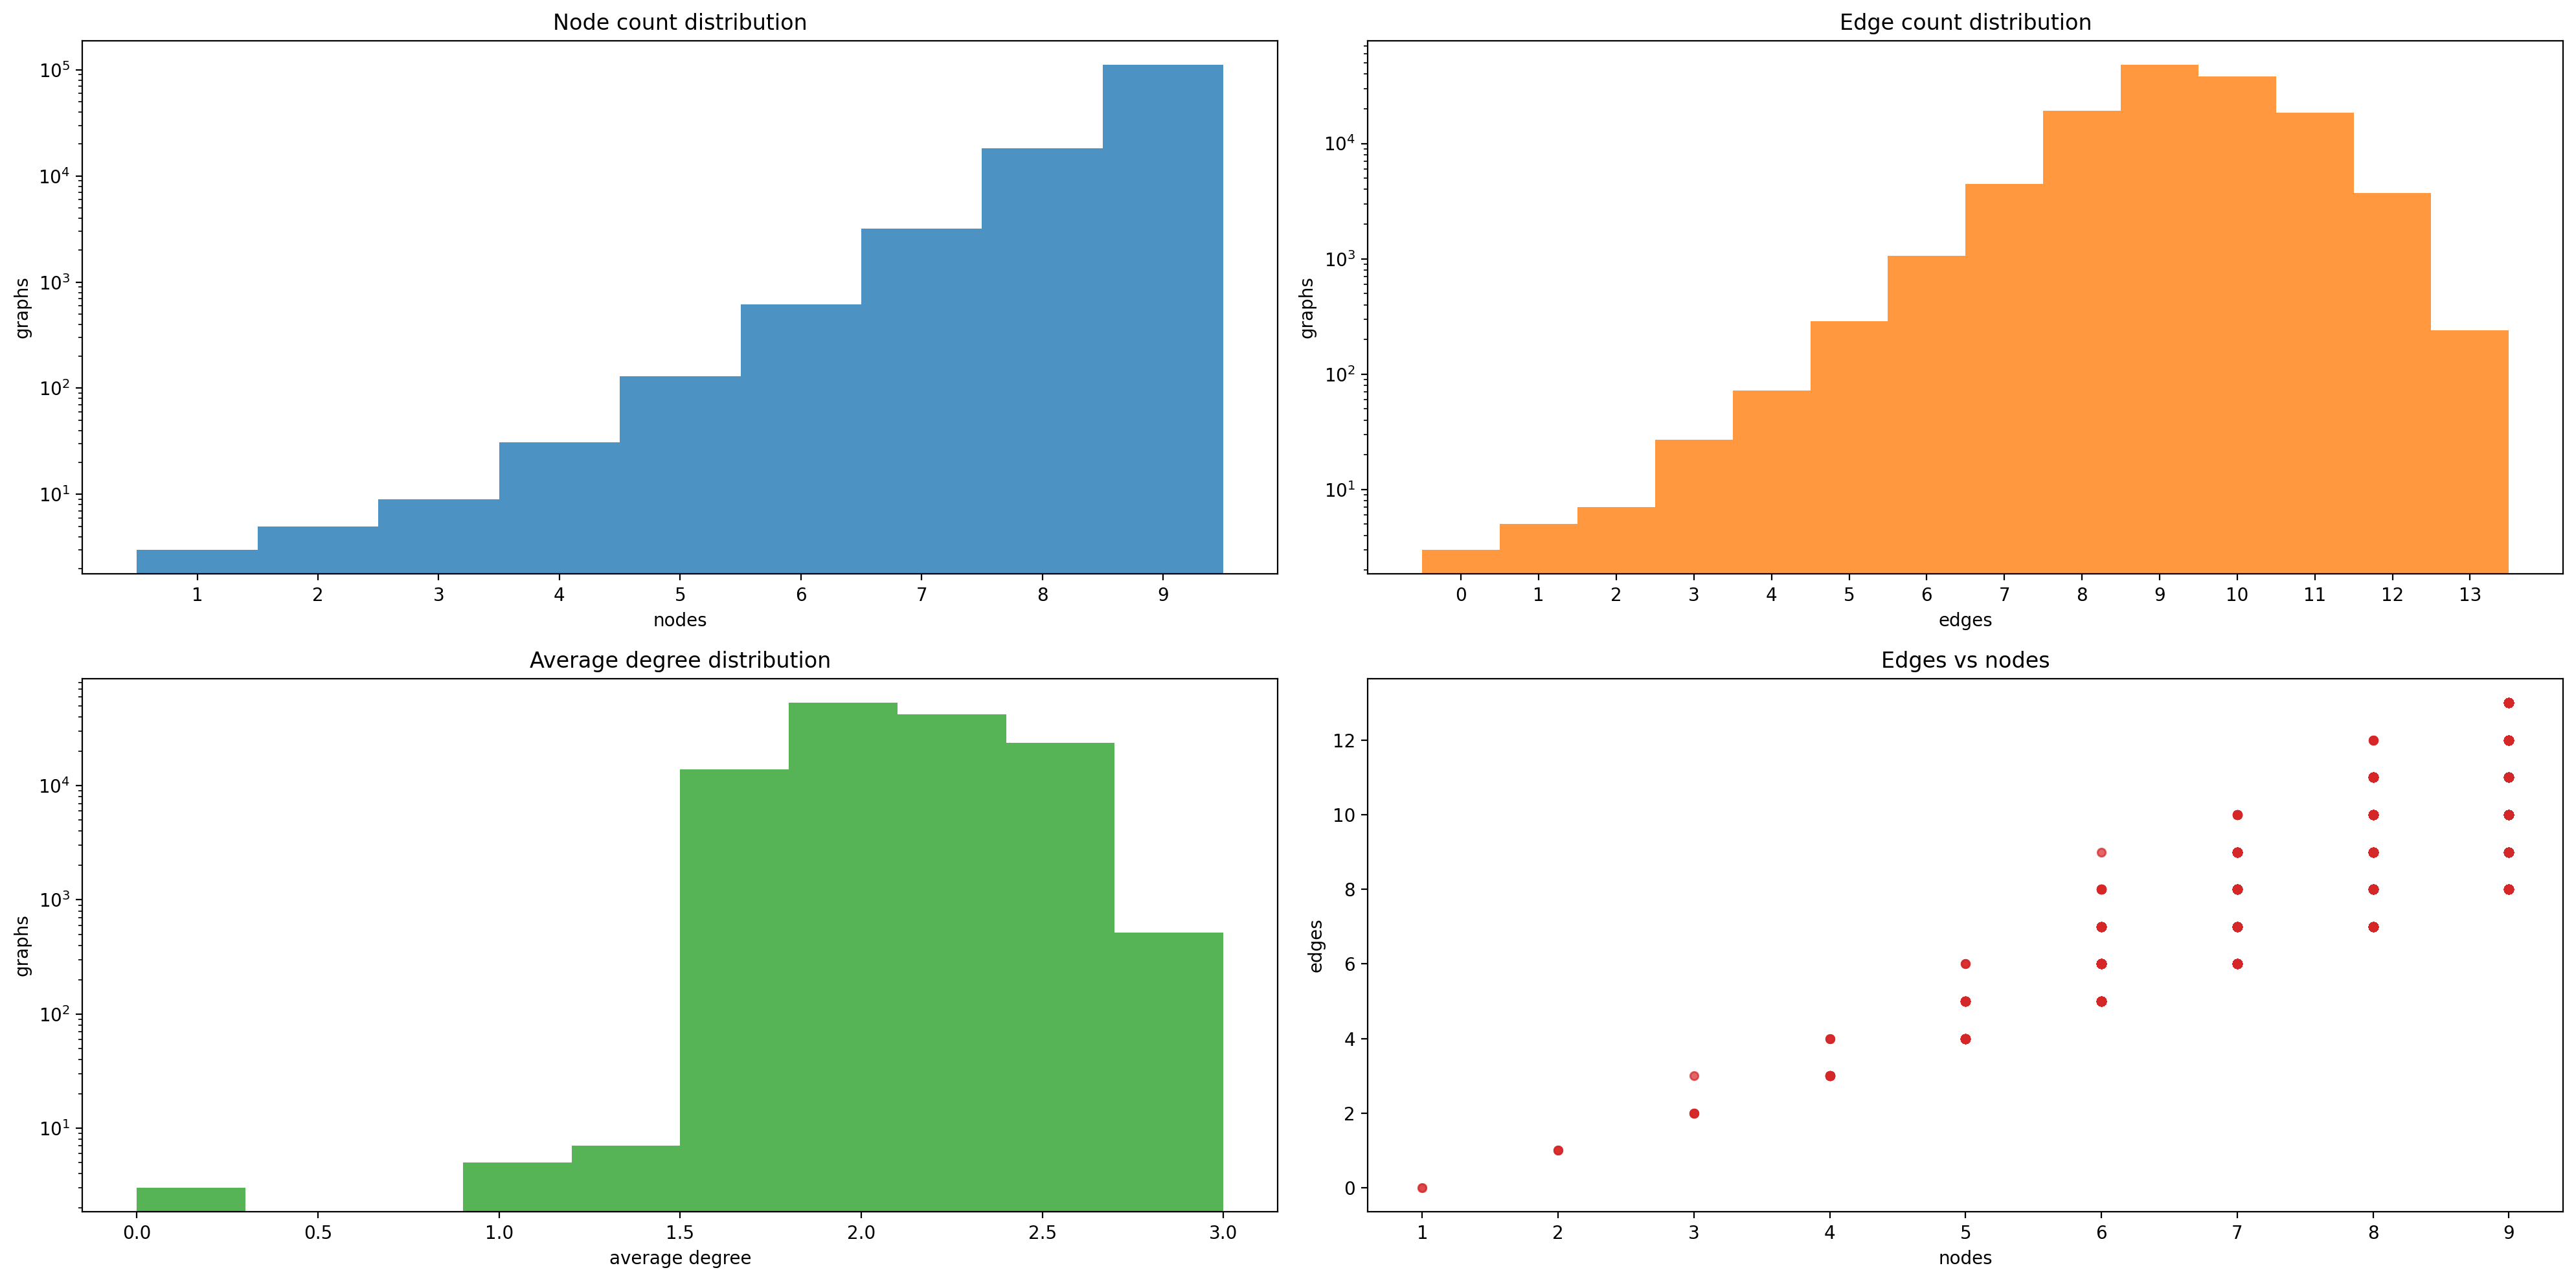

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

node_tick_values = np.arange(graph_stats["node_count"].min(), graph_stats["node_count"].max() + 1, 1)
node_bins = np.arange(graph_stats["node_count"].min() - 0.5, graph_stats["node_count"].max() + 1.5, 1)
edge_tick_values = np.arange(graph_stats["edge_count"].min(), graph_stats["edge_count"].max() + 1, 1)
edge_bins = np.arange(graph_stats["edge_count"].min() - 0.5, graph_stats["edge_count"].max() + 1.5, 1)

axes[0, 0].hist(graph_stats["node_count"], bins=node_bins, color="#1f77b4", alpha=0.8)
axes[0, 0].set_yscale("log")
axes[0, 0].set_xticks(node_tick_values)
axes[0, 0].set_title("Node count distribution")
axes[0, 0].set_xlabel("nodes")
axes[0, 0].set_ylabel("graphs")

axes[0, 1].hist(graph_stats["edge_count"], bins=edge_bins, color="#ff7f0e", alpha=0.8)
axes[0, 1].set_yscale("log")
axes[0, 1].set_xticks(edge_tick_values)
axes[0, 1].set_title("Edge count distribution")
axes[0, 1].set_xlabel("edges")
axes[0, 1].set_ylabel("graphs")

axes[1, 0].hist(graph_stats["average_degree"], bins=10, log=True, color="#2ca02c", alpha=0.8)
axes[1, 0].set_title("Average degree distribution")
axes[1, 0].set_xlabel("average degree")
axes[1, 0].set_ylabel("graphs")

axes[1, 1].scatter(graph_stats["node_count"], graph_stats["edge_count"], s=20, alpha=0.45, color="#d62728")
axes[1, 1].set_title("Edges vs nodes")
axes[1, 1].set_xlabel("nodes")
axes[1, 1].set_ylabel("edges")

plt.tight_layout()


In [55]:
summary = pd.DataFrame(
    {
        "graphs": [len(graph_stats)],
        "mean_nodes": [graph_stats["node_count"].mean()],
        "median_nodes": [graph_stats["node_count"].median()],
        "mean_edges": [graph_stats["edge_count"].mean()],
        "median_edges": [graph_stats["edge_count"].median()],
        "mean_density": [graph_stats["density"].mean()],
    },
    index=[dataset_name],
).round(3)

summary


,graphs,mean_nodes,median_nodes,mean_edges,median_edges,mean_density
qm9,133885,8.796,9.0,9.403,9.0,0.275


## QM9 target statistics

QM9 includes a standard family of molecular property targets. The next cells summarize the available target columns and draw histograms for a compact subset.


In [56]:
target_frame = metadata.loc[:, candidate_target_columns].copy()
display(target_frame.describe().transpose())

selected_target_columns = [column for column in ["mu", "alpha", "gap", "cv", "u0"] if column in target_frame.columns]
selected_target_columns


,count,mean,std,min,25%,50%,75%,max
A,133885.0,9.814382,1809.465666,0.000000,2.554430,3.090360,3.835820,619867.683140
B,133885.0,1.406097,1.583795,0.337120,1.091630,1.369940,1.653980,437.903860
C,133885.0,1.124921,1.095618,0.331180,0.910480,1.078560,1.279540,282.945450
mu,133885.0,2.706037,1.530394,0.000000,1.588700,2.500000,3.636100,29.556400
alpha,133885.0,75.191296,8.187793,6.310000,70.380000,75.500000,80.520000,196.620000
homo,133885.0,-0.239977,0.022131,-0.428600,-0.252500,-0.241000,-0.228700,-0.101700
lumo,133885.0,0.011124,0.046936,-0.175000,-0.023800,0.012000,0.049200,0.193500
gap,133885.0,0.251100,0.047519,0.024600,0.216300,0.249400,0.288200,0.622100
r2,133885.0,1189.527450,279.757172,19.000200,1018.322600,1147.585800,1308.816600,3374.753200
zpve,133885.0,0.148524,0.033274,0.015951,0.125289,0.148329,0.171150,0.273944


['mu', 'alpha', 'gap', 'cv', 'u0']

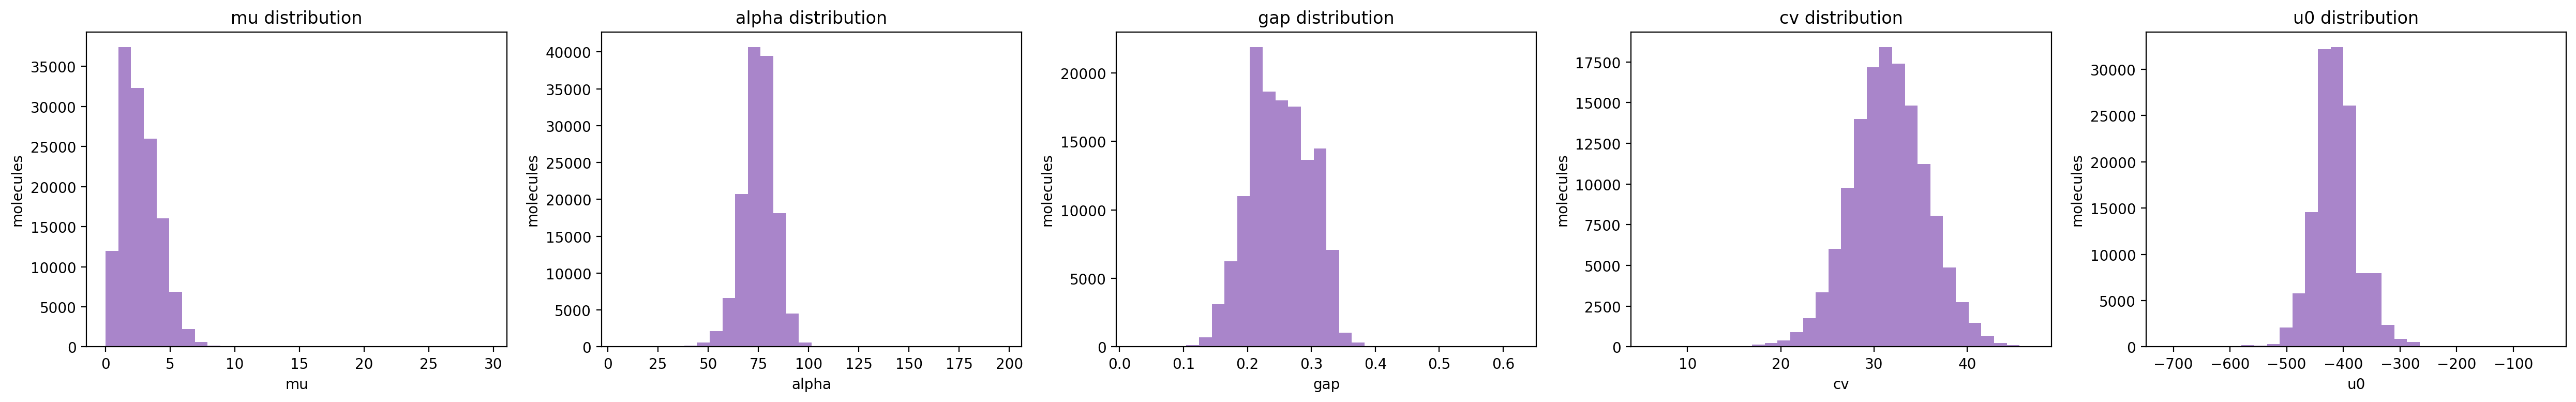

In [57]:
if selected_target_columns:
    fig, axes = plt.subplots(1, len(selected_target_columns), figsize=(5 * len(selected_target_columns), 4))
    if len(selected_target_columns) == 1:
        axes = [axes]

    for axis, column in zip(axes, selected_target_columns):
        axis.hist(target_frame[column].dropna(), bins=30, color="#9467bd", alpha=0.8)
        axis.set_title(f"{column} distribution")
        axis.set_xlabel(column)
        axis.set_ylabel("molecules")

    plt.tight_layout()
else:
    print("No QM9 target columns found in this dataset:", DEFAULT_QM9_TARGET_COLUMNS)
